In [ ]:
%pip install -r requirements.txt


In [ ]:
%pip install imbalanced-learn
%pip install --upgrade scikit-learn imbalanced-learn


In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE



In [107]:

features = ['slope_alpha', 'intercept_alpha', 'midband_alpha','slope_beta', 'intercept_beta', 'midband_beta','slope_gamma', 'intercept_gamma', 'midband_gamma','slope_delta', 'intercept_delta', 'midband_delta','label']

In [108]:
import random
eeg_idx = [1, 4, 5, 7, 9, 11, 13, 14, 15, 16, 17, 19, 20, 21, 22, 25, 31, 34,
           36, 38, 39, 40, 41, 44, 47, 50, 51, 52, 62, 63, 66, 67, 69, 73, 75,
           76, 77, 78, 79]

train = int(len(eeg_idx) * 0.75)
test = int(len(eeg_idx) * 0.25)
train_idx = random.sample(eeg_idx,train)
test_idx =[i for i in eeg_idx if i not in train_idx]



train_df = pd.DataFrame()
test_df = pd.DataFrame()

train_frames = []
test_frames = []

for i in train_idx:
    print(f'[TRAIN] Processing file {i}')
    sfilename = f'C:/bt23ece064/features/eeg{i}_seizure_features.csv'
    nsfilename = f'C:/bt23ece064/features/eeg{i}_non_seizure_features.csv'

    sdf = pd.read_csv(sfilename)
    nsdf = pd.read_csv(nsfilename)
    sdf['label'] = 1
    nsdf['label'] = 0

    train_frames.append(sdf[features])
    train_frames.append(nsdf[features])

train_df = pd.concat(train_frames, ignore_index=True)

for i in test_idx:
    print(f'[TEST] Processing file {i}')
    sfilename = f'C:/bt23ece064/features/eeg{i}_seizure_features.csv'
    nsfilename = f'C:/bt23ece064/features/eeg{i}_non_seizure_features.csv'

    sdf = pd.read_csv(sfilename)
    nsdf = pd.read_csv(nsfilename)
    sdf['label'] = 1
    nsdf['label'] = 0

    test_frames.append(sdf[features])
    test_frames.append(nsdf[features])

test_df = pd.concat(test_frames, ignore_index=True)

[TRAIN] Processing file 13
[TRAIN] Processing file 79
[TRAIN] Processing file 16
[TRAIN] Processing file 41
[TRAIN] Processing file 47
[TRAIN] Processing file 31
[TRAIN] Processing file 44
[TRAIN] Processing file 15
[TRAIN] Processing file 21
[TRAIN] Processing file 75
[TRAIN] Processing file 66
[TRAIN] Processing file 4
[TRAIN] Processing file 63
[TRAIN] Processing file 73
[TRAIN] Processing file 9
[TRAIN] Processing file 34
[TRAIN] Processing file 25
[TRAIN] Processing file 69
[TRAIN] Processing file 19
[TRAIN] Processing file 1
[TRAIN] Processing file 50
[TRAIN] Processing file 11
[TRAIN] Processing file 36
[TRAIN] Processing file 51
[TRAIN] Processing file 77
[TRAIN] Processing file 20
[TRAIN] Processing file 40
[TRAIN] Processing file 7
[TRAIN] Processing file 76
[TEST] Processing file 5
[TEST] Processing file 14
[TEST] Processing file 17
[TEST] Processing file 22
[TEST] Processing file 38
[TEST] Processing file 39
[TEST] Processing file 52
[TEST] Processing file 62
[TEST] Process

In [109]:
features = features[:-1]


# Replace inf with NaN and impute median in train
train_df[features] = train_df[features].replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy='median')
train_df[features] = imputer.fit_transform(train_df[features])

# Replace inf with NaN and impute median in test
test_df[features] = test_df[features].replace([np.inf, -np.inf], np.nan)
test_df[features] = imputer.transform(test_df[features])

# Extract features and labels
X_train = train_df[features].astype('float32').values
X_test = test_df[features].astype('float32').values

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['label'])
y_test = label_encoder.transform(test_df['label'])

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Remove SMOTE: use original training data**
X_train_resampled = X_train_scaled
y_train_resampled = y_train

print(f"Train size : {X_train_resampled.shape[0]}")

# Compute class weights (useful for imbalanced data)
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_resampled), y=y_train_resampled)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(f"Class weights: {class_weights_tensor}")

# Convert to PyTorch tensors
import torch
X_train_tensor = torch.tensor(X_train_resampled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

from collections import Counter
print(f"Class distribution: {Counter(y_train_resampled)}")



Train size : 3842
Class weights: tensor([0.6045, 2.8931])
Class distribution: Counter({np.int64(0): 3178, np.int64(1): 664})


In [110]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EEGDataset(X_train_scaled, y_train)
test_dataset = EEGDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [111]:
class NeuralNet(nn.Module):
    def __init__(self, input_dim):
        super(NeuralNet, self).__init__()
        self.net = nn.Sequential(
    nn.Linear(input_dim, 64),     
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.Dropout(0.3),
    
    nn.Linear(64, 32),            
    nn.ReLU(),
    nn.BatchNorm1d(32),
    nn.Dropout(0.2),
    
    nn.Linear(32, 16),           
    nn.ReLU(),
    nn.Dropout(0.1),
    
    nn.Linear(16, 8),
    nn.ReLU(),

    nn.Linear(8, 2),
    

    

)
               

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeuralNet(X_train_scaled.shape[1]).to(device)


In [112]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-7)


In [113]:
best_val_loss = float('inf')
patience = 20
epochs_no_improve = 0
history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(100):
    model.train()
    train_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    avg_train_loss = train_loss / total
    train_acc = correct / total

 
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    avg_val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f}, Train Acc {train_acc:.4f}, Val Loss {avg_val_loss:.4f}, Val Acc {val_acc:.4f}")

    history['loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

   
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pt")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break


model.load_state_dict(torch.load("best_model.pt"))


Epoch 1: Train Loss 0.6763, Train Acc 0.6041, Val Loss 0.7571, Val Acc 0.6040
Epoch 2: Train Loss 0.6559, Train Acc 0.7454, Val Loss 0.7093, Val Acc 0.6611
Epoch 3: Train Loss 0.6485, Train Acc 0.7582, Val Loss 0.8169, Val Acc 0.5874
Epoch 4: Train Loss 0.6477, Train Acc 0.7624, Val Loss 0.8499, Val Acc 0.6185
Epoch 5: Train Loss 0.6486, Train Acc 0.7538, Val Loss 0.8579, Val Acc 0.5955
Epoch 6: Train Loss 0.6408, Train Acc 0.7577, Val Loss 0.8348, Val Acc 0.6108
Epoch 7: Train Loss 0.6380, Train Acc 0.7520, Val Loss 0.9367, Val Acc 0.5853
Epoch 8: Train Loss 0.6338, Train Acc 0.7496, Val Loss 0.8607, Val Acc 0.6138
Epoch 9: Train Loss 0.6354, Train Acc 0.7644, Val Loss 0.7700, Val Acc 0.6662
Epoch 10: Train Loss 0.6319, Train Acc 0.7413, Val Loss 0.8130, Val Acc 0.6402
Epoch 11: Train Loss 0.6327, Train Acc 0.7655, Val Loss 0.8139, Val Acc 0.6176
Epoch 12: Train Loss 0.6262, Train Acc 0.7517, Val Loss 0.9018, Val Acc 0.6185
Epoch 13: Train Loss 0.6352, Train Acc 0.7465, Val Loss 0.855

<All keys matched successfully>


Confusion Matrix:
[[1333  656]
 [ 139  218]]

Classification Report:
              precision    recall  f1-score   support

     nonseiz       0.91      0.67      0.77      1989
        seiz       0.25      0.61      0.35       357

    accuracy                           0.66      2346
   macro avg       0.58      0.64      0.56      2346
weighted avg       0.81      0.66      0.71      2346



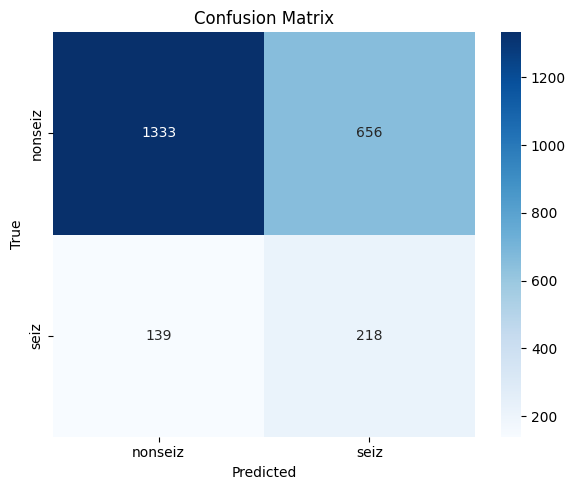

In [114]:
model.eval()
all_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, axis=1).cpu().numpy()
        all_preds.extend(preds)

cm = confusion_matrix(y_test, all_preds)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, all_preds, target_names=['nonseiz', 'seiz']))

# Confusion matrix plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['nonseiz', 'seiz'],
            yticklabels=['nonseiz', 'seiz'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


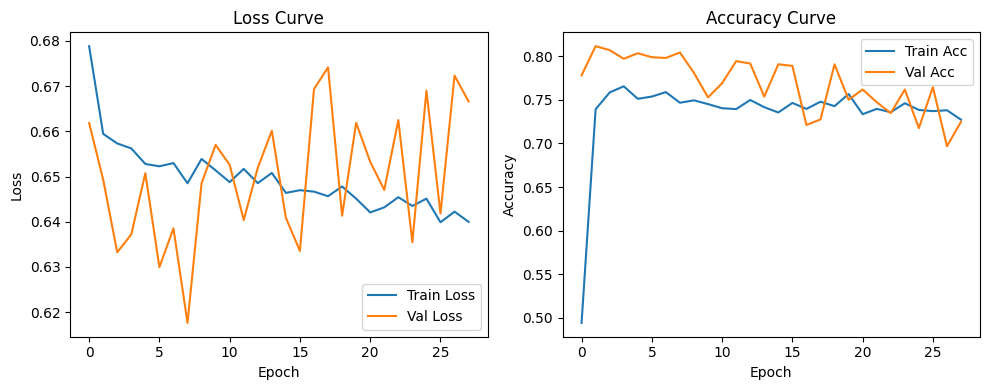

In [104]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Train Acc')
plt.plot(history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


[TRAIN] Processing file 44
[TRAIN] Processing file 22
[TRAIN] Processing file 15
[TRAIN] Processing file 69
[TRAIN] Processing file 67
[TRAIN] Processing file 11
[TRAIN] Processing file 7
[TRAIN] Processing file 14
[TRAIN] Processing file 9
[TRAIN] Processing file 39
[TRAIN] Processing file 73
[TRAIN] Processing file 50
[TRAIN] Processing file 40
[TRAIN] Processing file 21
[TRAIN] Processing file 38
[TRAIN] Processing file 5
[TRAIN] Processing file 20
[TRAIN] Processing file 41
[TRAIN] Processing file 47
[TRAIN] Processing file 78
[TRAIN] Processing file 31
[TRAIN] Processing file 77
[TRAIN] Processing file 1
[TRAIN] Processing file 76
[TRAIN] Processing file 17
[TRAIN] Processing file 34
[TRAIN] Processing file 51
[TRAIN] Processing file 66
[TRAIN] Processing file 63
[TEST] Processing file 4
[TEST] Processing file 13
[TEST] Processing file 16
[TEST] Processing file 19
[TEST] Processing file 25
[TEST] Processing file 36
[TEST] Processing file 52
[TEST] Processing file 62
[TEST] Process

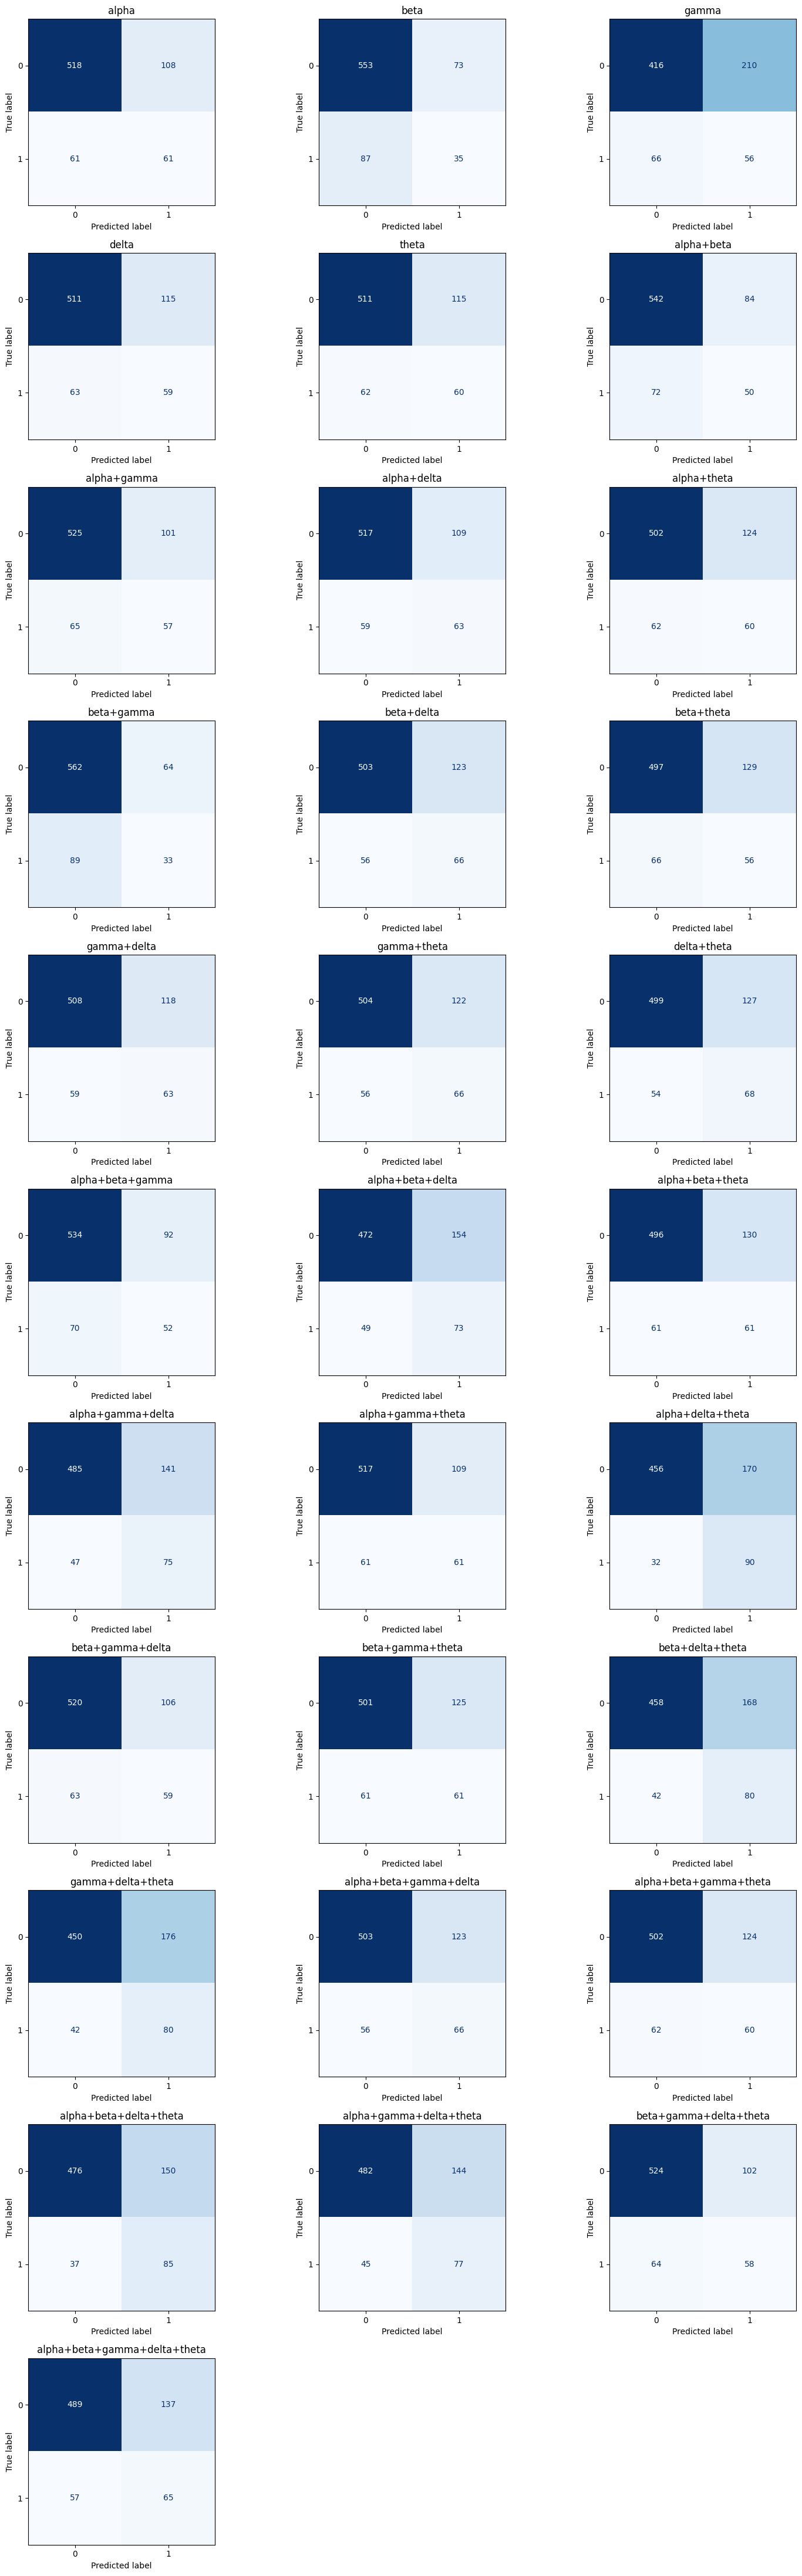

In [124]:
import random
import itertools
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

# --------------- Step 1: Preprocess EEG Data -------------------

eeg_idx = [1, 4, 5, 7, 9, 11, 13, 14, 15, 16, 17, 19, 20, 21, 22, 25, 31, 34,
           36, 38, 39, 40, 41, 44, 47, 50, 51, 52, 62, 63, 66, 67, 69, 73, 75,
           76, 77, 78, 79]

train_idx = random.sample(eeg_idx, int(len(eeg_idx) * 0.75))
test_idx = [i for i in eeg_idx if i not in train_idx]

train_frames = []
test_frames = []

for i in train_idx:
    print(f'[TRAIN] Processing file {i}')
    sfilename = f'C:/bt23ece064/features/eeg{i}_seizure_features.csv'
    nsfilename = f'C:/bt23ece064/features/eeg{i}_non_seizure_features.csv'
    sdf = pd.read_csv(sfilename)
    nsdf = pd.read_csv(nsfilename)
    sdf['label'] = 1
    nsdf['label'] = 0
    train_frames.append(sdf)
    train_frames.append(nsdf)

train_df = pd.concat(train_frames, ignore_index=True)

for i in test_idx:
    print(f'[TEST] Processing file {i}')
    sfilename = f'C:/bt23ece064/features/eeg{i}_seizure_features.csv'
    nsfilename = f'C:/bt23ece064/features/eeg{i}_non_seizure_features.csv'
    sdf = pd.read_csv(sfilename)
    nsdf = pd.read_csv(nsfilename)
    sdf['label'] = 1
    nsdf['label'] = 0
    test_frames.append(sdf)
    test_frames.append(nsdf)

test_df = pd.concat(test_frames, ignore_index=True)

# --------------- Step 2: Define Model -------------------

class NeuralNet(nn.Module):
    def __init__(self, input_dim):
        super(NeuralNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )

    def forward(self, x):
        return self.net(x)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------- Step 3: Train + Store Confusion Matrices -------------------

bands = ['alpha', 'beta', 'gamma', 'delta', 'theta']

conf_matrices = []
labels_for_plots = []

for r in range(1, len(bands)+1):
    for subset in itertools.combinations(bands, r):
        features = []
        for band in subset:
            features += [f"slope_{band}", f"intercept_{band}", f"midband_{band}"]

        # Prepare data subset
        train_subset = train_df[features + ['label']].copy()
        test_subset = test_df[features + ['label']].copy()

        # Replace inf and impute median
        train_subset[features] = train_subset[features].replace([np.inf, -np.inf], np.nan)
        test_subset[features] = test_subset[features].replace([np.inf, -np.inf], np.nan)

        imputer = SimpleImputer(strategy='median')
        train_subset[features] = imputer.fit_transform(train_subset[features])
        test_subset[features] = imputer.transform(test_subset[features])

        X_train = train_subset[features].astype('float32').values
        X_test = test_subset[features].astype('float32').values

        label_encoder = LabelEncoder()
        y_train = label_encoder.fit_transform(train_subset['label'])
        y_test = label_encoder.transform(test_subset['label'])

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        print(f"\nTraining subset: {subset}")
        print(f"Features count: {len(features)}")
        print(f"Train size: {X_train_scaled.shape[0]}, Test size: {X_test_scaled.shape[0]}")
        print(f"Train class distribution: {Counter(y_train)}")
        print(f"Test class distribution: {Counter(y_test)}")

        class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
        print(f"Class weights: {class_weights_tensor.cpu().numpy()}")

        X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.long)
        X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test, dtype=torch.long)

        train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
        test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)

        model = NeuralNet(X_train_tensor.shape[1]).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)

        best_val_loss = float('inf')
        patience = 20
        epochs_no_improve = 0

        for epoch in range(100):
            model.train()
            train_loss = 0
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()
                outputs = model(xb)
                loss = criterion(outputs, yb)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * xb.size(0)

            avg_train_loss = train_loss / len(train_loader.dataset)

            model.eval()
            val_loss = 0
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    outputs = model(xb)
                    loss = criterion(outputs, yb)
                    val_loss += loss.item() * xb.size(0)

            avg_val_loss = val_loss / len(test_loader.dataset)
            scheduler.step(avg_val_loss)

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                torch.save(model.state_dict(), "best_model.pt")
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    break

        model.load_state_dict(torch.load("best_model.pt"))
        model.eval()
        all_preds, all_true = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(DEVICE)
                out = model(xb)
                preds = out.argmax(1).cpu().numpy()
                all_preds.extend(preds)
                all_true.extend(yb.numpy())

        cm = confusion_matrix(all_true, all_preds)
        conf_matrices.append(cm)
        labels_for_plots.append('+'.join(subset))

        print(f"Completed training on subset: {subset}, Best val loss: {best_val_loss:.4f}")

# Plot all confusion matrices after training all subsets

num_plots = len(conf_matrices)
cols = 3
rows = (num_plots + cols - 1) // cols
plt.figure(figsize=(cols*5, rows*4))

for i, (cm, label) in enumerate(zip(conf_matrices, labels_for_plots), 1):
    plt.subplot(rows, cols, i)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=plt.gca(), cmap='Blues', colorbar=False)
    plt.title(label)
    plt.tight_layout()

plt.show()
